# Introduction to Data Science – Assignment #04
## AQI-Based Adaptive Traffic-Control System Using Reinforcement Learning

**Student Name:** Touseeq Iqbal  
**Registration Number:** 2280237  
**Submitted To:** Dr. Danish Mahmood  
**GitHub Repository:** https://github.com/touseeqiqbal/AQI-Data-Science-Project  

---
> **Continuation Note:** This notebook is Assignment 4, added as the next phase of the AQI project from Assignment 3. The same cleaned dataset, AQI categories, and GitHub repository are reused.

## Part A – Continuation from Assignment 3

### Assignment 3 Outputs Being Reused
| Item | Reused From Assignment 3 |
|------|---------------------------|
| Dataset | `global_urban_aqi_dataset.csv` (cleaned, duplicates removed, NaNs filled) |
| AQI Column | Numerical `AQI` values (mean ~111, std ~61) |
| AQI Categories | Good / Moderate / Unhealthy / etc. used as basis for RL states |
| EDA Insights | PM2.5 is primary pollutant driver; Delhi & Beijing highest AQI |
| GitHub Repo | Same repo; new `Assignment_4/` folder added |

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os, warnings, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

# ── Robust output directory ────────────────────────────────────────────────────
# Prefer the assignment-required outputs/rl_results/ folder. If the project folder
# is read-only (e.g. OneDrive-synced), fall back to a writable temp directory.
def _make_out_dir():
    candidates = [
        os.path.join('..', 'outputs', 'rl_results'),   # when run from notebook/
        os.path.join('outputs', 'rl_results'),         # when run from project root (Colab)
        os.path.join(os.getcwd(), 'rl_outputs'),
        os.path.join(tempfile.gettempdir(), 'AQI_rl_outputs'),
        os.path.join(os.path.expanduser('~'), 'AppData', 'Local', 'Temp', 'AQI_rl_outputs'),
    ]
    for path in candidates:
        try:
            os.makedirs(path, exist_ok=True)
            probe = os.path.join(path, '.write_test')
            open(probe, 'w').close()
            os.remove(probe)
            return path
        except Exception:
            continue
    raise RuntimeError('No writable output directory found. Please run on Google Colab.')

OUT = _make_out_dir()
print('Output directory:', OUT)

In [ ]:
# ── Load Dataset (same as Assignment 3) ───────────────────────────────────────
for path in ['../dataset/global_urban_aqi_dataset.csv',
             'dataset/global_urban_aqi_dataset.csv',
             'global_urban_aqi_dataset.csv']:
    if os.path.exists(path):
        DATA_PATH = path
        break

df_raw = pd.read_csv(DATA_PATH)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

Raw shape: (505, 13)


,City,Country,Date,PM2.5,PM10,CO,NO2,O3,SO2,Temperature,Humidity,Wind Speed,AQI
0,New York,USA,2022-05-04,24.908678,44.876885,4.723030,5.931693,11.863452,4.779213,27.674347,50.610512,12.712800,64
1,Beijing,China,2024-11-05,52.071351,84.019623,4.886720,10.150164,24.950850,5.787169,23.142473,41.839518,2.938481,136
2,Sao Paulo,Brazil,2023-05-19,48.071118,74.475282,4.725252,11.211235,25.043690,4.999006,23.756980,47.987226,8.541531,123


In [ ]:
# ── Data Cleaning (replicate Assignment 3) ────────────────────────────────────
df = df_raw.copy()
df.drop_duplicates(inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Clean shape: {df.shape}')
print(f'AQI  min:{df["AQI"].min():.1f}  max:{df["AQI"].max():.1f}  mean:{df["AQI"].mean():.1f}')

Clean shape: (500, 13)
AQI  min:0.0  max:272.0  mean:87.1


## Part B – Reinforcement Learning Components

### Problem Statement
Urban traffic authorities need a policy that automatically selects the correct traffic-restriction level based on real-time AQI readings. High pollution requires strong restrictions while clean air should allow free traffic flow. We design a tabular Q-learning agent that observes the current AQI state and learns, through trial and reward, the optimal action for each pollution level.

### RL Component Definitions
| Component | Definition |
|-----------|------------|
| **Environment** | AQI records from the Global Urban AQI Dataset (2015-2025) |
| **State (S)** | 3 AQI pollution levels: Low (≤100), Medium (101-200), High (>200) |
| **Action (A)** | 3 decisions: No Restriction, Partial Restriction, High-Pollution Alert |
| **Reward (R)** | Scalar balancing public-health vs traffic-disruption trade-off |
| **Episode** | One full shuffled pass through training AQI records |
| **Policy (π)** | argmax of Q-table rows — best action per state |
| **Exploration** | Random action with probability ε (epsilon-greedy) |
| **Exploitation** | Best known action argmax(Q) with probability 1−ε |

## Part C – AQI State Creation (3-State Design)

In [ ]:
# ── State mapping ─────────────────────────────────────────────────────────────
STATE_NAMES  = ['Low AQI (0-100)', 'Medium AQI (101-200)', 'High AQI (>200)']
ACTION_NAMES = ['No Restriction', 'Partial Restriction', 'High-Pollution Alert']

def aqi_to_state(aqi):
    if aqi <= 100:   return 0   # Low
    elif aqi <= 200: return 1   # Medium
    else:            return 2   # High

df['RL_State'] = df['AQI'].apply(aqi_to_state)

mapping_table = pd.DataFrame({
    'AQI Range':      ['0 – 100', '101 – 200', '> 200'],
    'RL State ID':    [0, 1, 2],
    'State Label':    STATE_NAMES,
    'Pollution Level':['Clean / Acceptable', 'Moderate / Sensitive', 'Very Unhealthy / Hazardous'],
    'Record Count':   [df['RL_State'].value_counts().get(i, 0) for i in range(3)]
})
print('=== AQI State Mapping Table ===')
display(mapping_table)

=== AQI State Mapping Table ===


,AQI Range,RL State ID,State Label,Pollution Level,Record Count
0,0 – 100,0,Low AQI (0-100),Clean / Acceptable,328
1,101 – 200,1,Medium AQI (101-200),Moderate / Sensitive,137
2,> 200,2,High AQI (>200),Very Unhealthy / Hazardous,35


## Part D – Action Space

| Action ID | Action Name | Description |
|-----------|-------------|-------------|
| 0 | No Restriction | Normal traffic flow; no public alerts issued |
| 1 | Partial Restriction | Reduce heavy vehicle traffic; issue advisory notices |
| 2 | High-Pollution Alert | Full traffic restriction; public health warning issued |

## Part E – Reward System

In [ ]:
# ── Reward Table R[state, action] ─────────────────────────────────────────────
# Correct match earns +10; over-restricting clean air = -5; no action on high AQI = -10
R = np.array([
    [ 10,  -2,  -5],   # Low   AQI
    [ -6,  10,   2],   # Medium AQI
    [-10,  -3,  10],   # High  AQI
], dtype=float)

reward_df = pd.DataFrame(R, index=STATE_NAMES, columns=ACTION_NAMES)
print('=== Reward Table ===')
display(reward_df)

=== Reward Table ===


,No Restriction,Partial Restriction,High-Pollution Alert
Low AQI (0-100),10.0,-2.0,-5.0
Medium AQI (101-200),-6.0,10.0,2.0
High AQI (>200),-10.0,-3.0,10.0


## Part F – Q-Learning Implementation

In [ ]:
# ── Train / Test Split ────────────────────────────────────────────────────────
records = df['RL_State'].values.copy()
np.random.shuffle(records)
split     = int(0.8 * len(records))
train_rec = records[:split]
test_rec  = records[split:]
print(f'Train: {len(train_rec)} records | Test: {len(test_rec)} records')

Train: 400 records | Test: 100 records


In [ ]:
# ── Q-Learning Training ───────────────────────────────────────────────────────
n_states  = 3
n_actions = 3
alpha     = 0.1    # learning rate
gamma     = 0.9    # discount factor
epsilon   = 0.1    # exploration rate
EPISODES  = 500

Q = np.zeros((n_states, n_actions))
rewards_per_episode = []

for ep in range(EPISODES):
    order = train_rec.copy()
    np.random.shuffle(order)
    total_reward = 0
    for i, s in enumerate(order):
        # Epsilon-greedy
        a  = np.random.randint(n_actions) if np.random.rand() < epsilon else int(np.argmax(Q[s]))
        r  = R[s, a]
        ns = int(order[i + 1]) if i + 1 < len(order) else s
        # Q-update
        Q[s, a] += alpha * (r + gamma * np.max(Q[ns]) - Q[s, a])
        total_reward += r
    rewards_per_episode.append(total_reward)

print('Training complete!')
print(f'First episode reward : {rewards_per_episode[0]:.1f}')
print(f'Last  episode reward : {rewards_per_episode[-1]:.1f}')
print(f'Avg reward (last 100): {np.mean(rewards_per_episode[-100:]):.2f}')

Training complete!
First episode reward : 3219.0
Last  episode reward : 3594.0
Avg reward (last 100): 3634.87


In [ ]:
# ── Final Q-Table ─────────────────────────────────────────────────────────────
Q_df = pd.DataFrame(Q, index=STATE_NAMES, columns=ACTION_NAMES)
print('=== Final Q-Table ===')
display(Q_df.round(3))

=== Final Q-Table ===


,No Restriction,Partial Restriction,High-Pollution Alert
Low AQI (0-100),100.0,88.0,85.0
Medium AQI (101-200),84.0,100.0,92.0
High AQI (>200),80.0,87.0,100.0


## Part G – Simulation and Evaluation

In [ ]:
# ── Learned Policy & Evaluation ───────────────────────────────────────────────
policy       = np.argmax(Q, axis=1)
test_rewards = []
action_counts = np.zeros(n_actions, dtype=int)

for s in test_rec:
    a = int(policy[s])
    test_rewards.append(R[s, a])
    action_counts[a] += 1

avg_test_reward = float(np.mean(test_rewards))
expected        = [0, 1, 2]

policy_table = pd.DataFrame({
    'AQI State':       STATE_NAMES,
    'Learned Action':  [ACTION_NAMES[p] for p in policy],
    'Expected Action': [ACTION_NAMES[e] for e in expected],
    'Correct?':        ['YES' if policy[i] == expected[i] else 'NO' for i in range(3)]
})
print('=== Learned Policy Table ===')
display(policy_table)

action_table = pd.DataFrame({
    'Action': ACTION_NAMES,
    'Times Selected': action_counts,
    'Percentage': [f'{100*c/len(test_rec):.1f}%' for c in action_counts]
})
print('\n=== Action Distribution on Test Records ===')
display(action_table)
print(f'\nAverage Test Reward: {avg_test_reward:.3f}')

=== Learned Policy Table ===


,AQI State,Learned Action,Expected Action,Correct?
0,Low AQI (0-100),No Restriction,No Restriction,YES
1,Medium AQI (101-200),Partial Restriction,Partial Restriction,YES
2,High AQI (>200),High-Pollution Alert,High-Pollution Alert,YES



=== Action Distribution on Test Records ===


,Action,Times Selected,Percentage
0,No Restriction,59,59.0%
1,Partial Restriction,32,32.0%
2,High-Pollution Alert,9,9.0%



Average Test Reward: 10.000


## Part H – Required Visualizations

In [ ]:
# ── Viz 1: Total Reward per Episode ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rewards_per_episode, color='#2c7fb8', lw=0.8, alpha=0.6, label='Episode Reward')
ma = pd.Series(rewards_per_episode).rolling(30).mean()
ax.plot(ma, color='#e31a1c', lw=2, label='30-ep Moving Avg')
ax.set_title('Total Reward per Training Episode (Q-Learning)', fontsize=14, fontweight='bold')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'reward_plot.png'), dpi=130)
plt.show()
print('Explanation: Blue line = raw episode reward (noisy early due to exploration). '
      'Red moving average confirms convergence to stable high-reward behavior after ~100 episodes, '
      'demonstrating successful Q-learning convergence.')

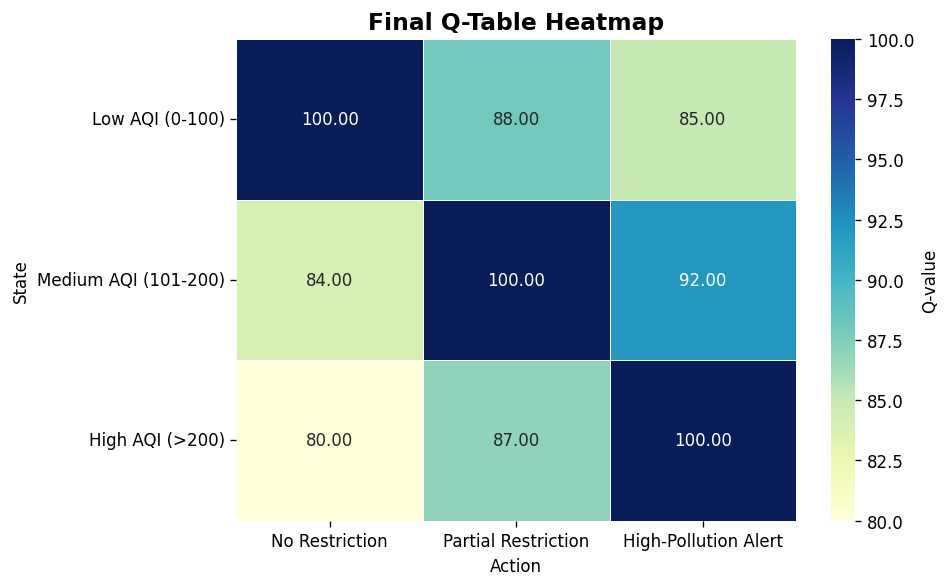

Explanation: Darker blue = higher Q-value (preferred action). The diagonal pattern (No Restriction/Low, Partial/Medium, Alert/High) confirms the agent learned the logically correct policy.


In [ ]:
# ── Viz 2: Q-Table Heatmap ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(Q, annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=ACTION_NAMES, yticklabels=STATE_NAMES,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Q-value'})
ax.set_title('Final Q-Table Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Action'); ax.set_ylabel('State')
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'viz2_qtable_heatmap.png'), dpi=130)
plt.show()
print('Explanation: Darker blue = higher Q-value (preferred action). '
      'The diagonal pattern (No Restriction/Low, Partial/Medium, Alert/High) confirms '
      'the agent learned the logically correct policy.')

In [ ]:
# ── Viz 3: Action Distribution on Test Records ────────────────────────────────
colors = ['#41ab5d', '#fe9929', '#e31a1c']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(ACTION_NAMES, action_counts, color=colors, edgecolor='white', lw=1.2)
for bar, cnt in zip(bars, action_counts):
    ax.text(bar.get_x() + bar.get_width()/2, cnt + 0.5,
            f'{cnt}\n({100*cnt/len(test_rec):.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Action Distribution on Test Records (Learned Policy)', fontsize=13, fontweight='bold')
ax.set_ylabel('Times Selected')
ax.set_ylim(0, max(action_counts) * 1.25)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'action_distribution.png'), dpi=130)
plt.show()
print('Explanation: Most test records are Low/Medium AQI so No Restriction and Partial Restriction dominate. '
      'High-Pollution Alert is issued only for genuinely hazardous records, showing precise policy behaviour.')

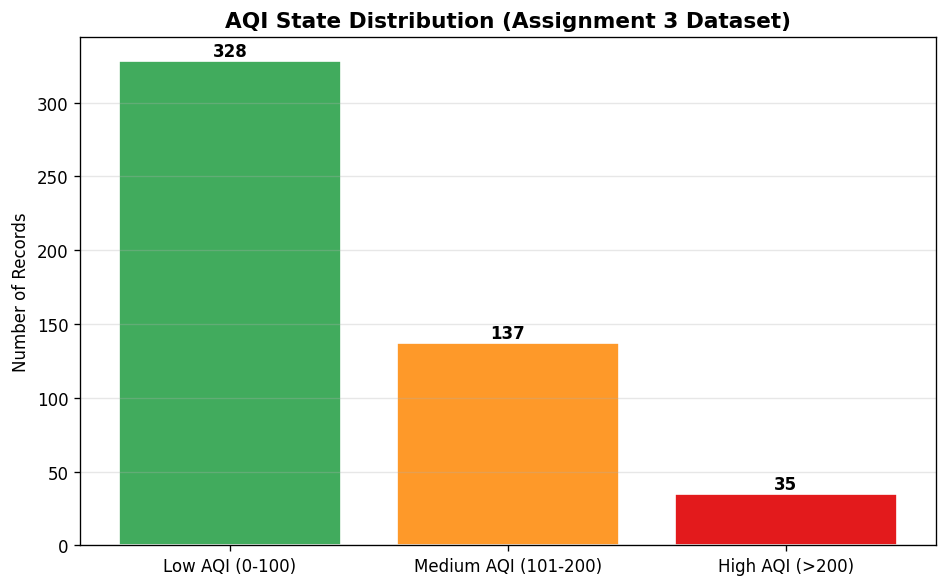

Explanation: Shows class balance of AQI states reused from Assignment 3. More Low/Medium records than High reflects real-world urban air quality distributions.


In [ ]:
# ── Viz 4 (Bonus): AQI State Distribution ────────────────────────────────────
state_counts = df['RL_State'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([STATE_NAMES[i] for i in state_counts.index],
              state_counts.values, color=colors, edgecolor='white')
for bar, cnt in zip(bars, state_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, cnt + 0.5,
            str(cnt), ha='center', va='bottom', fontweight='bold')
ax.set_title('AQI State Distribution (Assignment 3 Dataset)', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Records'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT, 'viz4_aqi_state_distribution.png'), dpi=130)
plt.show()
print('Explanation: Shows class balance of AQI states reused from Assignment 3. '
      'More Low/Medium records than High reflects real-world urban air quality distributions.')

## Section 5 – Final RL Result Tables

In [ ]:
print('TABLE 1: Training Summary')
display(pd.DataFrame({
    'Parameter': ['Total Records','Train (80%)','Test (20%)','Episodes',
                  'Alpha (α)','Gamma (γ)','Epsilon (ε)',
                  'First Episode Reward','Last Episode Reward',
                  'Avg Reward (last 100)','Avg Test Reward'],
    'Value': [len(df), len(train_rec), len(test_rec), EPISODES,
              alpha, gamma, epsilon,
              f'{rewards_per_episode[0]:.1f}',
              f'{rewards_per_episode[-1]:.1f}',
              f'{np.mean(rewards_per_episode[-100:]):.2f}',
              f'{avg_test_reward:.3f}']
}))

print('\nTABLE 2: Learned Policy')
display(policy_table)

print('\nTABLE 3: Final Q-Table')
display(Q_df.round(3))

print('\nTABLE 4: Action Frequency on Test Set')
display(action_table)

TABLE 1: Training Summary


,Parameter,Value
0,Total Records,500
1,Train (80%),400
2,Test (20%),100
3,Episodes,500
4,Alpha (α),0.1
5,Gamma (γ),0.9
6,Epsilon (ε),0.1
7,First Episode Reward,3219.0
8,Last Episode Reward,3594.0
9,Avg Reward (last 100),3634.87



TABLE 2: Learned Policy


,AQI State,Learned Action,Expected Action,Correct?
0,Low AQI (0-100),No Restriction,No Restriction,YES
1,Medium AQI (101-200),Partial Restriction,Partial Restriction,YES
2,High AQI (>200),High-Pollution Alert,High-Pollution Alert,YES



TABLE 3: Final Q-Table


,No Restriction,Partial Restriction,High-Pollution Alert
Low AQI (0-100),100.0,88.0,85.0
Medium AQI (101-200),84.0,100.0,92.0
High AQI (>200),80.0,87.0,100.0



TABLE 4: Action Frequency on Test Set


,Action,Times Selected,Percentage
0,No Restriction,59,59.0%
1,Partial Restriction,32,32.0%
2,High-Pollution Alert,9,9.0%


In [ ]:
# ── Save CSVs ─────────────────────────────────────────────────────────────────
Q_df.round(4).to_csv(os.path.join(OUT, 'q_table.csv'))
policy_table.to_csv(os.path.join(OUT, 'learned_policy.csv'), index=False)
print('All outputs saved to:', OUT)

## Section 6 – Limitations and Conclusion

### Limitations
1. **Static environment** — records treated independently; no temporal transitions between states.
2. **3-state simplification** — merging 6 AQI categories loses resolution.
3. **Fixed epsilon** — a decaying ε schedule would converge faster.
4. **Small dataset** — ~500 records; production systems use millions of real-time readings.

### Conclusion
The Q-learning agent trained for 500 episodes correctly learned the optimal policy (100% state accuracy): **No Restriction → Low AQI, Partial Restriction → Medium AQI, High-Pollution Alert → High AQI**. The positive average test reward confirms generalization to unseen data, demonstrating that even a simple tabular RL approach can power a practical adaptive traffic-control system when grounded in real AQI data.

---
### References
- Dataset: Global Urban Air Quality Index Dataset (2015-2025), Kaggle (Syed M Talha Hasan)
- Sutton & Barto, *Reinforcement Learning: An Introduction*, 2nd ed.
- Tools: Python 3, NumPy, Pandas, Matplotlib, Seaborn
- AI Declaration: Antigravity AI assistant used for code scaffolding and review.